
# MultiModal 구현하기

## <span class="mark">목표 : 정형 비정형을 합치자!</span>

## seg model 설정

In [1]:
seg_model = 'mask2former_r50_8xb2-epoch_1k_cbnu_solarpower_fold_1_0.001'
fold_num = 7


#  'mask2former_r50_8xb2-epoch_1k_cbnu_solarpower_fold_1_0.001',
#  'bisenetv1_r50-d32_4xb4-epoch_1k_cbnu_solarpower_fold_1_0.001',
#  'deeplabv3plus_r50-d8_4xb4-epoch_1k_cbnu_solarpower_fold_1_0.001',
#  'fcn_r50-d8_4xb4-epoch_1k_cbnu_solarpower_fold_1_0.001',
#  'ocrnet_r50-d8_4xb2-epoch_1k_cbnu_solarpower_fold_1_0.001']

## random seed 고정시키기

In [2]:
import numpy as np
import tensorflow as tf
import random as python_random 
import os

SEED = 42

np.random.seed(SEED)
python_random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_CUDNN_USE_FRONTEND '] = '1'

tf.__version__

2024-08-19 16:30:58.290484: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-19 16:30:58.381147: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-19 16:30:59.725661: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


'2.12.0'

## 폴더들 이름정하기
### logs 폴더 이름 정하기

In [3]:
import os
import os.path as osp
import datetime

now = datetime.datetime.now()
here = "/app/MultiModal/"

logs_folder = osp.join(here, 'logs', 'AAAI24-comparison',f"{now.strftime('%Y%m%d_%H%M%S.%f')}_AAAI24_fold_{fold_num}")

os.makedirs(logs_folder)
logs_folder 


'/app/MultiModal/logs/AAAI24-comparison/20240819_163102.837713_AAAI24_fold_7'

### 데이터셋 폴더들 변수 설정

In [4]:
datasets = {
    "soiling_folder" : "/app/MultiModal/dataset/seg_result_csv_20240723/",
    "cloud_folder" : "/app/MultiModal/dataset/preprocessed_20230912/cloud/classification/", #./dataset/preprocessed_20230905/cloud/classification/
    "table_folder" : "/app/MultiModal/dataset/preprocessed_20230912/table/",
}

In [5]:
options={"option":
            {"fusion method" : "middle",
            "created file name": "MultiModal_SolarPowerGenerationForecast-forCloudClassiciation"}
        }

In [6]:
import yaml

with open(osp.join(logs_folder, 'config.yaml'), 'w') as f:
    yaml.safe_dump(datasets, f, default_flow_style=False)
    yaml.safe_dump(options, f, default_flow_style=False)

## <span class="birk">구름 데이터로 예측하기</span>
- 구름 데이터로 정형 데이터에 들어갈 항목을 예측해보자?

- 구름 이미지를 classification해서 구름 유형을 구해서 정형에 넣기

### classification 결과 불러오기
- error : crop 데이터셋 이름에 panel1이 붙어나옴
- classificationScore.csv

In [7]:
import pandas as pd 

# 모든 행 출력
# pd.set_option('display.max_rows', None)

c_df = pd.read_csv(f'{datasets["cloud_folder"]}classificationScore.csv')
c_df

,Unnamed: 0,Unnamed: 0.1,name,A-sky,B-pattern,C-thick-dark,D-thick-white,E-veil
0,0,0,panel1_NVR_ch1_jpg_20230322164400.jpg,4.424425e-06,0.001453,12.288953,85.415357,2.294232
1,1,1,panel1_NVR_ch1_jpg_20230322164800.jpg,1.774776e-08,0.005228,1.871882,97.819990,0.302909
2,2,2,panel1_NVR_ch1_jpg_20230322165200.jpg,1.740531e-09,0.033978,39.807442,58.484578,1.673997
3,3,3,panel1_NVR_ch1_jpg_20230322165600.jpg,3.556563e-11,0.401890,0.855924,98.492891,0.249288
4,4,4,panel1_NVR_ch1_jpg_20230322170200.jpg,2.254395e-18,0.031208,52.248859,47.716528,0.003402
...,...,...,...,...,...,...,...,...
611,611,618,panel1_NVR_ch1_jpg_20230524150300.jpg,1.799946e-05,0.100269,97.112155,1.359047,1.428512
612,612,619,panel1_NVR_ch1_jpg_20230524150400.jpg,2.162626e-05,0.134633,96.143281,1.875569,1.846504
613,613,620,panel1_NVR_ch1_jpg_20230524150600.jpg,4.767913e-05,0.162092,95.125175,2.245099,2.467580
614,614,621,panel1_NVR_ch1_jpg_20230524150700.jpg,4.087786e-05,0.178127,95.569336,1.449511,2.802985


In [8]:
start = 19

for i in range(len(c_df)):
    c_df.loc[i, 'name'] = c_df.loc[i, 'name'][start:start+14]
    
c_df['name']=pd.to_datetime(c_df['name'])
c_df.rename(columns = {'name' :'일시'}, inplace = True)
c_df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"], inplace = True)
c_df

,일시,A-sky,B-pattern,C-thick-dark,D-thick-white,E-veil
0,2023-03-22 16:44:00,4.424425e-06,0.001453,12.288953,85.415357,2.294232
1,2023-03-22 16:48:00,1.774776e-08,0.005228,1.871882,97.819990,0.302909
2,2023-03-22 16:52:00,1.740531e-09,0.033978,39.807442,58.484578,1.673997
3,2023-03-22 16:56:00,3.556563e-11,0.401890,0.855924,98.492891,0.249288
4,2023-03-22 17:02:00,2.254395e-18,0.031208,52.248859,47.716528,0.003402
...,...,...,...,...,...,...
611,2023-05-24 15:03:00,1.799946e-05,0.100269,97.112155,1.359047,1.428512
612,2023-05-24 15:04:00,2.162626e-05,0.134633,96.143281,1.875569,1.846504
613,2023-05-24 15:06:00,4.767913e-05,0.162092,95.125175,2.245099,2.467580
614,2023-05-24 15:07:00,4.087786e-05,0.178127,95.569336,1.449511,2.802985


In [9]:
c_df.loc[i, '일시']

Timestamp('2023-05-24 15:08:00')

## <span class="birk">오염 데이터로 예측하기</span>
- 오염 데이터로 정형 데이터에 들어갈 항목을 예측해보자?

- 오염 이미지를 seg -> 오염별로 몇퍼 있는지 체크해서 정형에 넣기

### seg 결과 가져오기
"soiling_folder" : "./dataset/preprocessed_20230908/soiling/seg/"


In [10]:
import pandas as pd 

# 모든 행 출력
# pd.set_option('display.max_rows', None)

s_df = pd.read_csv(f'{datasets["soiling_folder"]}{seg_model}.csv')
s_df

,Unnamed: 0,name,panel number,panel,bird dropping,pine pollen,plastic bag,sand,shadow
0,0,panel1_NVR_ch2_jpg_20230403093600.npy,1,90.777412,0.0,0.000000,0.000000,9.222588,0.000000
1,1,panel2_NVR_ch2_jpg_20230329145000.npy,2,23.871930,0.0,76.128070,0.000000,0.000000,0.000000
2,2,panel2_NVR_ch2_jpg_20230410172900.npy,2,69.862496,0.0,0.000000,0.000000,30.137504,0.000000
3,3,panel2_NVR_ch2_jpg_20230424143600.npy,2,19.163848,0.0,0.000000,0.000000,80.836152,0.000000
4,4,panel3_NVR_ch2_jpg_20230424093100.npy,3,90.861962,0.0,0.000000,0.000000,9.138038,0.000000
...,...,...,...,...,...,...,...,...,...
1702,1702,panel2_NVR_ch2_jpg_20230417134300.npy,2,51.056871,0.0,0.000000,0.000000,48.943129,0.000000
1703,1703,panel2_NVR_ch2_jpg_20230524143400.npy,2,81.020826,0.0,0.000000,18.979174,0.000000,0.000000
1704,1704,panel2_NVR_ch2_jpg_20230424173200.npy,2,58.735315,0.0,0.000000,0.000000,41.264685,0.000000
1705,1705,panel1_NVR_ch2_jpg_20230424134600.npy,1,61.612229,0.0,38.387771,0.000000,0.000000,0.000000


In [11]:
start = 19

for i in range(len(s_df)):
    s_df.loc[i, 'name'] = s_df.loc[i, 'name'][start:-4]
    
s_df['name']=pd.to_datetime(s_df['name'])
s_df.rename(columns = {'name' :'일시'}, inplace = True)

s_df.drop(columns=["Unnamed: 0"], inplace = True)
s_df

,일시,panel number,panel,bird dropping,pine pollen,plastic bag,sand,shadow
0,2023-04-03 09:36:00,1,90.777412,0.0,0.000000,0.000000,9.222588,0.000000
1,2023-03-29 14:50:00,2,23.871930,0.0,76.128070,0.000000,0.000000,0.000000
2,2023-04-10 17:29:00,2,69.862496,0.0,0.000000,0.000000,30.137504,0.000000
3,2023-04-24 14:36:00,2,19.163848,0.0,0.000000,0.000000,80.836152,0.000000
4,2023-04-24 09:31:00,3,90.861962,0.0,0.000000,0.000000,9.138038,0.000000
...,...,...,...,...,...,...,...,...
1702,2023-04-17 13:43:00,2,51.056871,0.0,0.000000,0.000000,48.943129,0.000000
1703,2023-05-24 14:34:00,2,81.020826,0.0,0.000000,18.979174,0.000000,0.000000
1704,2023-04-24 17:32:00,2,58.735315,0.0,0.000000,0.000000,41.264685,0.000000
1705,2023-04-24 13:46:00,1,61.612229,0.0,38.387771,0.000000,0.000000,0.000000


## 전처리 : 정형과 비정형을 일대일 매칭하기
### 전처리된 table 가져오기

In [12]:
import pandas as pd 


df = pd.read_csv(f'{datasets["table_folder"]}weather-addSoilingType_examine_1_upload_preprocessed.csv')
df['일시']=pd.to_datetime(df['일시'])
df.drop(columns=["Unnamed: 0"], inplace = True)
df

,일시,기온(°C),풍속(m/s),습도(%),일사(MJ/m^2),power generation,panel number,reduction amount(%),soiling type
0,2023-03-22 16:44:00,24.8,0.6,35.1,0.01,30.253643,1,36.465219,sand
1,2023-03-22 16:48:00,24.8,0.3,35.5,0.02,18.711142,1,58.466150,sand
2,2023-03-22 16:52:00,25.1,1.6,35.4,0.03,18.002813,1,64.198553,sand
3,2023-03-22 16:56:00,24.7,1.9,35.6,0.02,14.933952,1,68.404315,sand
4,2023-03-22 17:02:00,24.6,2.2,36.0,0.00,23.847889,1,44.150064,sand
...,...,...,...,...,...,...,...,...,...
2312,2023-05-24 15:03:00,27.0,2.2,19.4,0.05,186.958420,4,NaN,clean
2313,2023-05-24 15:04:00,26.8,2.1,19.4,0.02,182.557648,4,NaN,clean
2314,2023-05-24 15:06:00,26.6,2.3,19.6,0.02,173.983704,4,NaN,clean
2315,2023-05-24 15:07:00,26.6,1.7,20.7,0.06,181.806000,4,NaN,clean


### 구름, 오염  값 넣기

In [13]:
df = df.merge(c_df)
df = df.merge(s_df)
df

,일시,기온(°C),풍속(m/s),습도(%),일사(MJ/m^2),power generation,panel number,reduction amount(%),soiling type,A-sky,B-pattern,C-thick-dark,D-thick-white,E-veil,panel,bird dropping,pine pollen,plastic bag,sand,shadow
0,2023-03-22 16:44:00,24.8,0.6,35.1,0.01,30.253643,1,36.465219,sand,4.424425e-06,0.001453,12.288953,85.415357,2.294232,49.708526,0.0,50.291474,0.0,0.000000,0.000000
1,2023-03-22 16:44:00,24.8,0.6,35.1,0.01,24.392439,2,48.774160,sand,4.424425e-06,0.001453,12.288953,85.415357,2.294232,98.475881,0.0,0.000000,0.0,1.524119,0.000000
2,2023-03-22 16:48:00,24.8,0.3,35.5,0.02,18.711142,1,58.466150,sand,1.774776e-08,0.005228,1.871882,97.819990,0.302909,30.980776,0.0,69.019224,0.0,0.000000,0.000000
3,2023-03-22 16:48:00,24.8,0.3,35.5,0.02,28.045124,2,37.747146,sand,1.774776e-08,0.005228,1.871882,97.819990,0.302909,97.568085,0.0,0.000000,0.0,2.431915,0.000000
4,2023-03-22 16:52:00,25.1,1.6,35.4,0.03,18.002813,1,64.198553,sand,1.740531e-09,0.033978,39.807442,58.484578,1.673997,17.363831,0.0,0.000000,0.0,82.636169,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1697,2023-03-29 09:37:00,10.0,0.2,53.4,0.02,97.584610,3,58.562632,pine_pollen,9.338147e-06,0.001163,86.476457,0.059971,13.462400,52.836864,0.0,47.163136,0.0,0.000000,0.000000
1698,2023-04-24 13:50:00,19.3,1.8,33.1,0.04,209.644501,2,24.191194,sand,6.056611e-05,0.100286,23.777393,75.137615,0.984654,41.059986,0.0,0.000000,0.0,58.940014,0.000000
1699,2023-04-24 13:50:00,19.3,1.8,33.1,0.04,141.665619,3,48.772797,shadow,6.056611e-05,0.100286,23.777393,75.137615,0.984654,88.289872,0.0,0.000000,0.0,0.000000,11.710128
1700,2023-04-24 14:19:00,19.1,2.3,30.7,0.07,100.309685,2,64.007697,sand,2.752144e-03,6.597699,75.231808,8.512820,9.654919,9.827786,0.0,0.000000,0.0,90.172214,0.000000


### Train, test, val split
- train : test : val = 7:2:1

#### Train , test 나누기

In [14]:
ttv = ['train', 'test', 'val']

tables_dic = {}

for i in ttv:
    tables_dic[i] = pd.read_csv(f'/app/MultiModal/dataset/k_fold_20240627/fold_{fold_num}/table/{i}.csv', index_col=0)
    tables_dic[i]['일시']=pd.to_datetime(tables_dic[i]['일시'])
    tables_dic[i].drop(columns=["soiling type"], inplace = True)
    
    left = tables_dic[i].reset_index().rename(columns={'index': 'original_index'})
    merged_df = pd.merge(left=left, right=df, how='left', 
                         on=['일시', '기온(°C)', '풍속(m/s)', '습도(%)', '일사(MJ/m^2)', 'power generation','panel number'],
                         sort=False)
    tables_dic[i]=merged_df.set_index('original_index')
    
    

In [15]:
tables_dic['train']

,일시,기온(°C),풍속(m/s),습도(%),일사(MJ/m^2),power generation,panel number,reduction amount(%),soiling type,A-sky,B-pattern,C-thick-dark,D-thick-white,E-veil,panel,bird dropping,pine pollen,plastic bag,sand,shadow
original_index,,,,,,,,,,,,,,,,,,,,
2,2023-03-22 16:52:00,25.1,1.6,35.4,0.03,18.002813,1,64.198553,sand,1.740531e-09,0.033978,39.807442,58.484578,1.673997,17.363831,0.0,0.0,0.000000,82.636169,0.000000
3,2023-03-22 16:56:00,24.7,1.9,35.6,0.02,14.933952,1,68.404315,sand,3.556563e-11,0.401890,0.855924,98.492891,0.249288,10.464133,0.0,0.0,0.000000,89.535867,0.000000
4,2023-03-22 17:02:00,24.6,2.2,36.0,0.00,23.847889,1,44.150064,sand,2.254395e-18,0.031208,52.248859,47.716528,0.003402,94.028124,0.0,0.0,0.000000,5.971876,0.000000
7,2023-03-29 09:29:00,9.4,0.7,55.9,0.03,74.881966,1,63.458934,shadow,6.471734e-05,0.000112,49.240392,0.063785,50.695640,99.572802,0.0,0.0,0.000000,0.000000,0.427198
8,2023-03-29 09:42:00,10.0,0.4,51.2,0.03,33.043358,1,86.974791,sand,4.871554e-06,0.000778,39.441219,0.033145,60.524851,66.213510,0.0,0.0,0.000000,33.786490,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,2023-05-24 15:00:00,27.2,1.7,21.3,0.03,16.136250,3,91.248738,plastic_bag,3.603223e-05,0.091109,98.089910,0.765836,1.053107,86.583304,0.0,0.0,13.416696,0.000000,0.000000
1698,2023-05-24 15:04:00,26.8,2.1,19.4,0.02,31.162500,3,82.930049,plastic_bag,2.162626e-05,0.134633,96.143281,1.875569,1.846504,79.369883,0.0,0.0,20.630117,0.000000,0.000000
1699,2023-05-24 15:06:00,26.6,2.3,19.6,0.02,35.029736,3,79.866082,plastic_bag,4.767913e-05,0.162092,95.125175,2.245099,2.467580,86.525454,0.0,0.0,13.474546,0.000000,0.000000


In [16]:
tables_dic['val']

,일시,기온(°C),풍속(m/s),습도(%),일사(MJ/m^2),power generation,panel number,reduction amount(%),soiling type,A-sky,B-pattern,C-thick-dark,D-thick-white,E-veil,panel,bird dropping,pine pollen,plastic bag,sand,shadow
original_index,,,,,,,,,,,,,,,,,,,,
0,2023-03-22 16:44:00,24.8,0.6,35.1,0.01,30.253643,1,36.465219,sand,4.424425e-06,0.001453,12.288953,85.415357,2.294232,49.708526,0.000000,50.291474,0.000000,0.000000,0.000000
5,2023-03-29 09:17:00,8.8,0.4,55.2,0.03,79.253433,1,66.139578,shadow,2.822049e-02,0.000180,14.607355,0.442075,84.922165,99.886525,0.000000,0.000000,0.000000,0.000000,0.113475
16,2023-03-29 14:42:00,19.7,0.6,16.9,0.05,98.613510,1,51.831093,pine_pollen,5.187550e-01,4.000583,14.370240,4.274743,76.835668,0.269224,0.000000,99.730776,0.000000,0.000000,0.000000
21,2023-03-29 15:07:00,19.8,1.3,18.5,0.03,106.689651,1,36.546096,pine_pollen,2.919647e-02,2.097867,32.838190,6.272288,58.762461,0.823247,0.000000,99.176753,0.000000,0.000000,0.000000
40,2023-04-03 10:15:00,17.2,1.8,23.5,0.04,156.545166,1,44.903684,sand,5.170496e-03,1.063354,74.121261,6.877874,17.932339,26.751068,0.000000,0.000000,0.000000,73.248932,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1651,2023-05-24 10:16:00,21.2,0.7,45.4,0.02,162.363098,3,6.187677,bird_dropping,1.399274e-08,0.001689,99.908340,0.030097,0.059867,97.372286,2.627714,0.000000,0.000000,0.000000,0.000000
1666,2023-05-24 14:22:00,26.2,1.4,26.5,0.04,80.994568,3,66.649447,plastic_bag,1.159363e-04,0.190138,66.663325,30.058110,3.088315,88.848345,0.000000,0.000000,11.151655,0.000000,0.000000
1669,2023-05-24 14:26:00,26.4,2.4,24.3,0.07,57.599342,3,77.754135,plastic_bag,1.232137e-05,0.112394,70.460755,26.517376,2.909456,73.845230,0.000000,0.000000,26.154770,0.000000,0.000000


In [17]:
tables_dic['test']

,일시,기온(°C),풍속(m/s),습도(%),일사(MJ/m^2),power generation,panel number,reduction amount(%),soiling type,A-sky,B-pattern,C-thick-dark,D-thick-white,E-veil,panel,bird dropping,pine pollen,plastic bag,sand,shadow
original_index,,,,,,,,,,,,,,,,,,,,
1,2023-03-22 16:48:00,24.8,0.3,35.5,0.02,18.711142,1,58.466150,sand,1.774776e-08,0.005228,1.871882,97.819990,0.302909,30.980776,0.0,69.019224,0.000000,0.0,0.00000
6,2023-03-29 09:25:00,9.2,0.2,55.4,0.03,96.024139,1,57.922594,shadow,1.896276e-03,0.000218,29.134721,0.314629,70.548540,99.879850,0.0,0.000000,0.000000,0.0,0.12015
12,2023-03-29 14:26:00,19.7,1.5,15.0,0.05,141.794998,1,35.986188,pine_pollen,9.952065e-03,1.467593,12.762883,3.229250,82.530314,1.722143,0.0,98.277857,0.000000,0.0,0.00000
17,2023-03-29 14:46:00,20.2,1.2,18.0,0.05,80.496284,1,59.792847,pine_pollen,3.598477e-01,5.864248,8.056875,4.331289,81.387746,0.349324,0.0,99.650676,0.000000,0.0,0.00000
22,2023-03-29 16:41:00,20.7,1.7,12.8,0.02,46.068752,1,36.937261,pine_pollen,3.519209e-03,0.110537,54.112697,16.863148,28.910094,2.089267,0.0,97.910733,0.000000,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,2023-05-24 14:36:00,27.2,1.4,21.1,0.03,36.225426,3,73.754059,plastic_bag,1.057065e-05,0.009114,98.232424,1.489270,0.269181,80.802777,0.0,0.000000,19.197223,0.0,0.00000
1682,2023-05-24 14:43:00,26.4,2.8,20.0,0.02,55.357311,3,58.174320,plastic_bag,2.801901e-06,0.004472,99.166369,0.685689,0.143466,81.552599,0.0,0.000000,18.447401,0.0,0.00000
1687,2023-05-24 14:50:00,26.7,1.6,20.1,0.03,48.224346,3,78.580880,plastic_bag,2.264698e-05,0.012253,97.515863,2.009413,0.462445,77.881363,0.0,0.000000,22.118637,0.0,0.00000


In [18]:
tables_dic['train']['일시'].dt.date.value_counts(normalize=True)

2023-04-24    0.279966
2023-05-01    0.160101
2023-04-10    0.159262
2023-05-24    0.158424
2023-04-17    0.134116
2023-04-03    0.061190
2023-03-29    0.041911
2023-03-22    0.005029
Name: 일시, dtype: float64

In [19]:
tables_dic['test']['일시'].dt.date.value_counts(normalize=True)

2023-04-24    0.288235
2023-04-10    0.164706
2023-05-24    0.158824
2023-05-01    0.150000
2023-04-17    0.129412
2023-04-03    0.058824
2023-03-29    0.044118
2023-03-22    0.005882
Name: 일시, dtype: float64

In [20]:
tables_dic['val']['일시'].dt.date.value_counts(normalize=True)

2023-04-24    0.284024
2023-05-24    0.159763
2023-05-01    0.159763
2023-04-10    0.159763
2023-04-17    0.124260
2023-04-03    0.053254
2023-03-29    0.047337
2023-03-22    0.011834
Name: 일시, dtype: float64

In [21]:
tables_dic['train']['soiling type'].value_counts(normalize=True)

pine_pollen      0.329422
sand             0.268231
plastic_bag      0.160101
bird_dropping    0.146689
shadow           0.095557
Name: soiling type, dtype: float64

In [22]:
tables_dic['train']['soiling type'].value_counts()

pine_pollen      393
sand             320
plastic_bag      191
bird_dropping    175
shadow           114
Name: soiling type, dtype: int64

In [23]:
tables_dic['test']['soiling type'].value_counts(normalize=True)

pine_pollen      0.332353
sand             0.267647
plastic_bag      0.155882
bird_dropping    0.150000
shadow           0.094118
Name: soiling type, dtype: float64

In [24]:
tables_dic['test']['soiling type'].value_counts()

pine_pollen      113
sand              91
plastic_bag       53
bird_dropping     51
shadow            32
Name: soiling type, dtype: int64

In [25]:
tables_dic['val']['soiling type'].value_counts(normalize=True)

pine_pollen      0.325444
sand             0.272189
bird_dropping    0.153846
plastic_bag      0.153846
shadow           0.094675
Name: soiling type, dtype: float64

In [26]:
tables_dic['val']['soiling type'].value_counts()

pine_pollen      55
sand             46
bird_dropping    26
plastic_bag      26
shadow           16
Name: soiling type, dtype: int64

### df 합치기

In [27]:
df = tables_dic['train']
df=df.append(tables_dic['test'])
df=df.append(tables_dic['val'])
df

,일시,기온(°C),풍속(m/s),습도(%),일사(MJ/m^2),power generation,panel number,reduction amount(%),soiling type,A-sky,B-pattern,C-thick-dark,D-thick-white,E-veil,panel,bird dropping,pine pollen,plastic bag,sand,shadow
original_index,,,,,,,,,,,,,,,,,,,,
2,2023-03-22 16:52:00,25.1,1.6,35.4,0.03,18.002813,1,64.198553,sand,1.740531e-09,0.033978,39.807442,58.484578,1.673997,17.363831,0.000000,0.0,0.000000,82.636169,0.000000
3,2023-03-22 16:56:00,24.7,1.9,35.6,0.02,14.933952,1,68.404315,sand,3.556563e-11,0.401890,0.855924,98.492891,0.249288,10.464133,0.000000,0.0,0.000000,89.535867,0.000000
4,2023-03-22 17:02:00,24.6,2.2,36.0,0.00,23.847889,1,44.150064,sand,2.254395e-18,0.031208,52.248859,47.716528,0.003402,94.028124,0.000000,0.0,0.000000,5.971876,0.000000
7,2023-03-29 09:29:00,9.4,0.7,55.9,0.03,74.881966,1,63.458934,shadow,6.471734e-05,0.000112,49.240392,0.063785,50.695640,99.572802,0.000000,0.0,0.000000,0.000000,0.427198
8,2023-03-29 09:42:00,10.0,0.4,51.2,0.03,33.043358,1,86.974791,sand,4.871554e-06,0.000778,39.441219,0.033145,60.524851,66.213510,0.000000,0.0,0.000000,33.786490,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1651,2023-05-24 10:16:00,21.2,0.7,45.4,0.02,162.363098,3,6.187677,bird_dropping,1.399274e-08,0.001689,99.908340,0.030097,0.059867,97.372286,2.627714,0.0,0.000000,0.000000,0.000000
1666,2023-05-24 14:22:00,26.2,1.4,26.5,0.04,80.994568,3,66.649447,plastic_bag,1.159363e-04,0.190138,66.663325,30.058110,3.088315,88.848345,0.000000,0.0,11.151655,0.000000,0.000000
1669,2023-05-24 14:26:00,26.4,2.4,24.3,0.07,57.599342,3,77.754135,plastic_bag,1.232137e-05,0.112394,70.460755,26.517376,2.909456,73.845230,0.000000,0.0,26.154770,0.000000,0.000000


In [28]:
df.columns

Index(['일시', '기온(°C)', '풍속(m/s)', '습도(%)', '일사(MJ/m^2)', 'power generation',
       'panel number', 'reduction amount(%)', 'soiling type', 'A-sky',
       'B-pattern', 'C-thick-dark', 'D-thick-white', 'E-veil', 'panel',
       'bird dropping', 'pine pollen', 'plastic bag', 'sand', 'shadow'],
      dtype='object')

## <span class="birk">정형 데이터로 예측하기</span>


### X, y 나누기

In [29]:
from sklearn.preprocessing import MinMaxScaler

def X_y_split(df1, tables_dic, X_col_list):
    
    X = df1[X_col_list]
    X = X.sort_index()
    
    y = df1['power generation']
    y = y.sort_index() 
    y=pd.DataFrame(y)
    

    x_scaler = MinMaxScaler() #0~1사이의 값으로 정규화해주는 함수
    y_scaler = MinMaxScaler()

    X_norm, y_norm = X.copy(), y.copy()
    X_norm.iloc[:, :] = x_scaler.fit_transform(X_norm.iloc[:, :])
    y_norm.iloc[:, :] = y_scaler.fit_transform(y_norm.iloc[:, :])

    print('X_norm.shape, y_norm.shape : ', X_norm.shape, y_norm.shape)
    
    
    X_train = X_norm.loc[tables_dic['train'].index] 
    X_test = X_norm.loc[tables_dic['test'].index]
    X_val = X_norm.loc[tables_dic['val'].index]
    
    y_train = y_norm.loc[tables_dic['train'].index]
    y_test = y_norm.loc[tables_dic['test'].index] 
    y_val = y_norm.loc[tables_dic['val'].index]
    
    print('train, test, val : ', X_train.shape, X_test.shape, X_val.shape)
    
    return (X_train, X_test, X_val, y_train, y_test, y_val, y_scaler)

### model들

In [30]:
from keras import models
from keras import layers
from tensorflow.keras import optimizers


def DNN(input_shape): 
    tf.keras.backend.clear_session()
    initializer = tf.keras.initializers.GlorotUniform(seed=SEED)
    
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu',
                           input_shape=(input_shape[1],), kernel_initializer=initializer))
    model.add(layers.Dense(64, activation='relu', kernel_initializer=initializer))
    model.add(layers.Dense(1, activation = 'sigmoid', kernel_initializer=initializer))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

### train

In [31]:
from itertools import *
dataset = {'weather':
           ['기온(°C)','풍속(m/s)','습도(%)','일사(MJ/m^2)',],
           'sunlight':
           ['A-sky','B-pattern','C-thick-dark','D-thick-white','E-veil'],
           'soiling':
           ['panel','bird dropping','pine pollen','plastic bag','sand','shadow'],
          }


X_col_dic = {}
for i in range(1,4):
    print(list(combinations(dataset.keys(), i)))
    
    for com in list(combinations(dataset.keys(), i)):
        columns = [] 
        for c in com:
            columns += dataset[c]
        X_col_dic["_".join(com)] = columns


[('weather',), ('sunlight',), ('soiling',)]
[('weather', 'sunlight'), ('weather', 'soiling'), ('sunlight', 'soiling')]
[('weather', 'sunlight', 'soiling')]


In [32]:
X_col_dic

{'weather': ['기온(°C)', '풍속(m/s)', '습도(%)', '일사(MJ/m^2)'],
 'sunlight': ['A-sky', 'B-pattern', 'C-thick-dark', 'D-thick-white', 'E-veil'],
 'soiling': ['panel',
  'bird dropping',
  'pine pollen',
  'plastic bag',
  'sand',
  'shadow'],
 'weather_sunlight': ['기온(°C)',
  '풍속(m/s)',
  '습도(%)',
  '일사(MJ/m^2)',
  'A-sky',
  'B-pattern',
  'C-thick-dark',
  'D-thick-white',
  'E-veil'],
 'weather_soiling': ['기온(°C)',
  '풍속(m/s)',
  '습도(%)',
  '일사(MJ/m^2)',
  'panel',
  'bird dropping',
  'pine pollen',
  'plastic bag',
  'sand',
  'shadow'],
 'sunlight_soiling': ['A-sky',
  'B-pattern',
  'C-thick-dark',
  'D-thick-white',
  'E-veil',
  'panel',
  'bird dropping',
  'pine pollen',
  'plastic bag',
  'sand',
  'shadow'],
 'weather_sunlight_soiling': ['기온(°C)',
  '풍속(m/s)',
  '습도(%)',
  '일사(MJ/m^2)',
  'A-sky',
  'B-pattern',
  'C-thick-dark',
  'D-thick-white',
  'E-veil',
  'panel',
  'bird dropping',
  'pine pollen',
  'plastic bag',
  'sand',
  'shadow']}

In [33]:
class GradCallback(tf.keras.callbacks.TensorBoard):
    def __init__(self, model_logs_directory, x, y):
        super(GradCallback, self).__init__(log_dir=model_logs_directory, histogram_freq=1, 
                                           write_graph=True, update_freq='epoch',profile_batch=2)
        
        self.x = x
        self.y = y
    
    def on_epoch_end(self, epoch, logs={}):
        super().on_epoch_end(epoch, logs)
        
        model = self.model
        
        with tf.GradientTape(persistent=True, watch_accessed_variables=True) as tape:
            tape.watch(model.trainable_weights)
            
            x = []
            for xs in self.x:
                x.append(tf.convert_to_tensor(xs))
            
            pred = model(x)
            loss = tf.keras.losses.mean_squared_error(self.y, pred)

        
            grads={}

            for layer in model.layers:
                if (layer.name[0] == '0') or (layer.name[0] == '1') or (layer.name[0] == '2') or (layer.name[0] == '3'):
                    grads[layer.name]=tape.gradient(loss, layer.trainable_weights)
            
        tf.summary.experimental.set_step(epoch)
        
        writer = self._train_writer
        
        with writer.as_default():
            for layer_name, g in grads.items():
                curr_grad = g[0]
                mean = tf.math.reduce_mean(tf.abs(curr_grad))
                tf.summary.scalar(f'{layer_name}_grad_mean', mean)
                tf.summary.histogram(f'{layer_name}_grad_histogram', curr_grad, epoch)

In [34]:
import numpy as np
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from pickle import dump

  
num_epochs= 1000


historys = {}


for combi_name, X_col_list in X_col_dic.items() : 
    print(">>>>>>>>>>")
    print(f"combi name : {combi_name}, X_col_list : {X_col_list}")
    
    tf.keras.backend.clear_session()

    (X_train, X_test, X_val, y_train, y_test, y_val, y_scaler) =X_y_split(df.copy(), tables_dic.copy(), X_col_list)

    os.makedirs(osp.join(logs_folder,combi_name), exist_ok= True)
    
    X_test.to_csv(f"{logs_folder}/{combi_name}/X_test.csv")
    y_test.to_csv(f"{logs_folder}/{combi_name}/y_test.csv")
    dump(y_scaler, open(f"{logs_folder}/{combi_name}/y_scaler.pkl", 'wb'))

    es = EarlyStopping(monitor='val_loss', patience=10)
    tb = tf.keras.callbacks.TensorBoard(log_dir=osp.join(logs_folder,combi_name), histogram_freq=1)
    best_check = ModelCheckpoint(filepath=f"{logs_folder}/{combi_name}/best_model.h5", 
                                 monitor="val_loss",
                                 save_best_only=True,
                                 save_weights_only=False,
                                )
    
    model = DNN(X_train.shape)

    historys[combi_name]= model.fit(X_train, y_train, 
                                                epochs=num_epochs, batch_size=4,
                                                validation_data = (X_val, y_val),
                                                verbose =1, callbacks=[es, best_check, tb])

>>>>>>>>>>
combi name : weather, X_col_list : ['기온(°C)', '풍속(m/s)', '습도(%)', '일사(MJ/m^2)']
X_norm.shape, y_norm.shape :  (1702, 4) (1702, 1)
train, test, val :  (1193, 4) (340, 4) (169, 4)


2024-08-19 16:31:19.470507: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/1000


2024-08-19 16:31:19.869727: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [1193,4]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:31:19.870248: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype double and shape [1193,1]
	 [[{{node Placeholder/_11}}]]


287/299 [===========================>..] - ETA: 0s - loss: 0.0420 - mae: 0.1737

...

299/299 [==============================] - 3s 5ms/step - loss: 0.0477 - mae: 0.1855 - val_loss: 0.0428 - val_mae: 0.1711
Epoch 2/1000
299/299 [==============================] - 2s 8ms/step - loss: 0.0368 - mae: 0.1591 - val_loss: 0.0421 - val_mae: 0.1617
Epoch 3/1000
299/299 [==============================] - 1s 4ms/step - loss: 0.0350 - mae: 0.1517 - val_loss: 0.0400 - val_mae: 0.1587
Epoch 4/1000
299/299 [==============================] - 2s 6ms/step - loss: 0.0335 - mae: 0.1483 - val_loss: 0.0394 - val_mae: 0.1562
Epoch 5/1000
299/299 [==============================] - 2s 5ms/step - loss: 0.0326 - mae: 0.1447 - val_loss: 0.0406 - val_mae: 0.1577
Epoch 6/1000
299/299 [==============================] - 1s 4ms/step - loss: 0.0310 - mae: 0.1404 - val_loss: 0.0381 - val_mae: 0.1500
Epoch 7/1000
299/299 [==============================] - 2s 7ms/step - loss: 0.0303 - mae: 0.1377 - val_loss: 0.0365 - val_mae: 0.1452
Epoch 8/1000
299/299 [==============================] - 1s 3ms/step - loss:

2024-08-19 16:37:07.797211: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [1193,15]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:37:07.797854: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype double and shape [1193,1]
	 [[{{node Placeholder/_11}}]]


294/299 [============================>.] - ETA: 0s - loss: 0.0360 - mae: 0.1576

2024-08-19 16:37:09.482127: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype double and shape [169,1]
	 [[{{node Placeholder/_11}}]]
2024-08-19 16:37:09.482697: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype double and shape [169,1]
	 [[{{node Placeholder/_11}}]]


299/299 [==============================] - 2s 5ms/step - loss: 0.0357 - mae: 0.1569 - val_loss: 0.0236 - val_mae: 0.1291
Epoch 2/1000
299/299 [==============================] - 2s 8ms/step - loss: 0.0210 - mae: 0.1152 - val_loss: 0.0217 - val_mae: 0.1206
Epoch 3/1000
299/299 [==============================] - 1s 4ms/step - loss: 0.0186 - mae: 0.1057 - val_loss: 0.0190 - val_mae: 0.1105
Epoch 4/1000
299/299 [==============================] - 2s 7ms/step - loss: 0.0172 - mae: 0.1009 - val_loss: 0.0175 - val_mae: 0.1058
Epoch 5/1000
299/299 [==============================] - 1s 4ms/step - loss: 0.0157 - mae: 0.0950 - val_loss: 0.0166 - val_mae: 0.1005
Epoch 6/1000
299/299 [==============================] - 2s 5ms/step - loss: 0.0140 - mae: 0.0889 - val_loss: 0.0166 - val_mae: 0.1000
Epoch 7/1000
299/299 [==============================] - 2s 6ms/step - loss: 0.0133 - mae: 0.0863 - val_loss: 0.0137 - val_mae: 0.0875
Epoch 8/1000
299/299 [==============================] - 1s 4ms/step - loss:

### learning curve

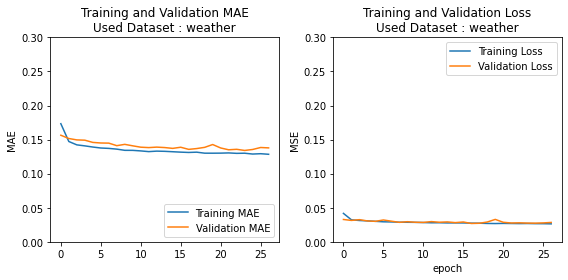

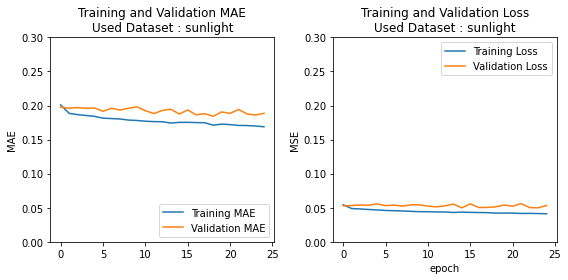

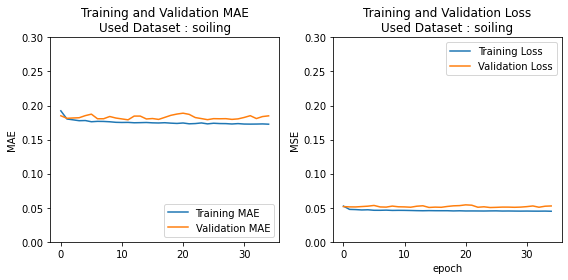

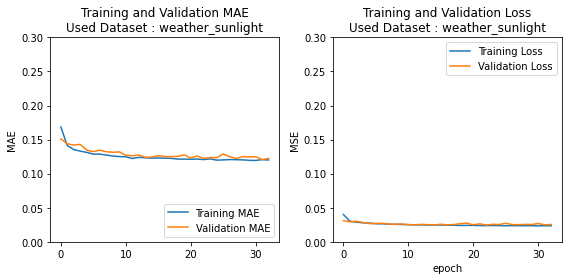

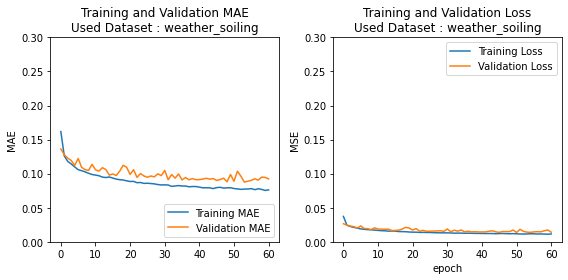

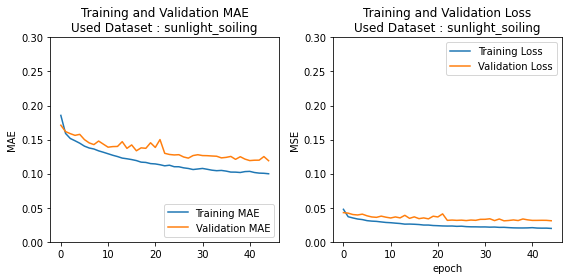

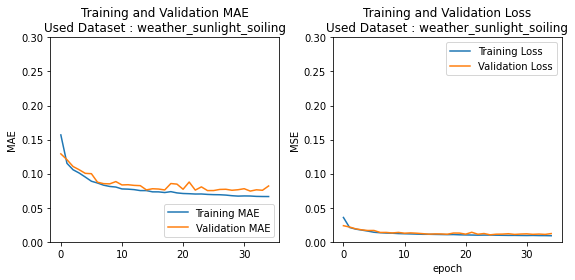

In [35]:
import matplotlib.pyplot as plt

for combi_name in historys.keys():
    #train
    mae = historys[combi_name].history['mae']
    loss = historys[combi_name].history['loss']

    #val
    val_mae = historys[combi_name].history['val_mae']
    val_loss = historys[combi_name].history['val_loss']



    #graph 
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(mae, label='Training MAE')
    plt.plot(val_mae, label='Validation MAE')
    plt.legend(loc='lower right')
    plt.ylabel('MAE')
    plt.ylim([0,0.3])
    plt.title(f'Training and Validation MAE\nUsed Dataset : {combi_name}')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.ylabel('MSE')
    plt.ylim([0,0.3])
    plt.title(f'Training and Validation Loss\nUsed Dataset : {combi_name}')
    plt.xlabel('epoch')

    plt.tight_layout() 

    plt.savefig(f'{logs_folder}/{combi_name}/learning_curve.png', facecolor='#eeeeee') 

    plt.show()

### evaluate

In [36]:
from sklearn.metrics import r2_score #R^2
from sklearn.metrics import mean_squared_error #MSE
from sklearn.metrics import mean_absolute_error #MAE

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    MSE = mean_squared_error(y_true, y_pred) 
    rmse = np.sqrt(MSE)
    mae = mean_absolute_error(y_true, y_pred)
    return np.round(r2*100, 10), np.round(rmse, 10), np.round(mae, 10)

11/11 [==============================] - 0s 3ms/step


2024-08-19 16:38:16.207418: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,4]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:16.207799: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,4]
	 [[{{node Placeholder/_10}}]]


----------------
combi name : weather
 R2: 56.3481703203, RMSE: 49.3436932004, MAE: 40.4532575408
----------------
11/11 [==============================] - 0s 2ms/step


2024-08-19 16:38:16.530466: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,5]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:16.530824: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,5]
	 [[{{node Placeholder/_10}}]]


----------------
combi name : sunlight
 R2: 24.098714433, RMSE: 65.0661322607, MAE: 55.071378175
----------------
11/11 [==============================] - 0s 2ms/step


...

----------------
combi name : weather_soiling
 R2: 78.5046366138, RMSE: 34.6260396078, MAE: 24.368557795
----------------
11/11 [==============================] - 0s 2ms/step


2024-08-19 16:38:17.777548: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,11]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:17.777938: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,11]
	 [[{{node Placeholder/_10}}]]


----------------
combi name : sunlight_soiling
 R2: 58.3649795967, RMSE: 48.1903207219, MAE: 34.7820005254
----------------


2024-08-19 16:38:18.535798: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,15]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:18.541946: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,15]
	 [[{{node Placeholder/_10}}]]


11/11 [==============================] - 0s 9ms/step
----------------
combi name : weather_sunlight_soiling
 R2: 81.2623386337, RMSE: 32.3286908895, MAE: 22.4365250531
----------------


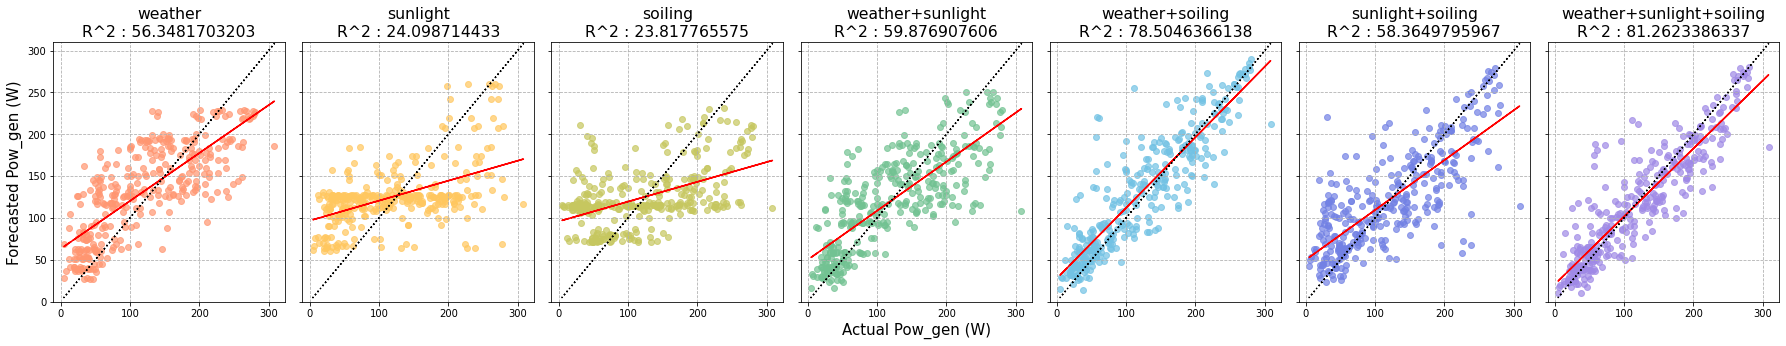

In [37]:
from sklearn.linear_model import LinearRegression
from pickle import load
from silence_tensorflow import silence_tensorflow
import warnings
import matplotlib.pyplot as plt


f_summary = open(f"{logs_folder}/result_summary.txt","w+")
f_summary.write("----------------\n")

results = {}


# 2x3 그리드에 산점도 그리기
fig, axes = plt.subplots(1, len(historys.keys()), figsize=(25, 5),
                         sharex=True, sharey=True)

# Matplotlib의 기본 스타일 설정 변경
plt.rcParams['font.size'] = 13  # 전체 글꼴 크기
plt.rcParams['axes.labelsize'] = 10  # 축 레이블 크기
# plt.rcParams['xtick.labelsize'] = 10  # x축 눈금 레이블 크기
# plt.rcParams['ytick.labelsize'] = 10  # y축 눈금 레이블 크기
colors= ['#FF9671','#FFC75F','#C6C75F','#72C292','#72C2E4','#7281E4','#9F89E6']


for i, combi_name in enumerate(historys.keys()):
    results[combi_name] = {}
    # 저장했던거 불러오기
    X_test = pd.read_csv(f"{logs_folder}/{combi_name}/X_test.csv", index_col=0)
    y_test = pd.read_csv(f"{logs_folder}/{combi_name}/y_test.csv", index_col=0)

    model = models.load_model(f"{logs_folder}/{combi_name}/best_model.h5")
    scaler = load(open(f"{logs_folder}/{combi_name}/y_scaler.pkl", 'rb'))

    y_test_inv = y_scaler.inverse_transform(y_test)

    y_forecast = model.predict(X_test)
    y_forecast_inv = y_scaler.inverse_transform(y_forecast)
    y_forecast_inv = y_forecast_inv#.clip(min=0)

    r2, rmse, mae = evaluate(y_test_inv, y_forecast_inv)

    print("----------------")
    print(f"combi name : {combi_name}\n R2: {r2}, RMSE: {rmse}, MAE: {mae}")
    print("----------------")

    results[combi_name]["r2"] = r2
    results[combi_name]["rmse"] = rmse
    results[combi_name]["mae"] = mae

    f_summary.write(f"combi name : {combi_name}\n\t R2: {r2}, RMSE: {rmse}, MAE: {mae}\n\n")
    
    ## 그래프 그리기
    lr = LinearRegression()
    lr.fit(y_test_inv, y_forecast_inv)

    axes[i].grid(visible=True, linestyle='--',  axis='y')
    axes[i].grid(visible=True, linestyle='--',  axis='x')

    axes[i].scatter(y_test_inv, y_forecast_inv, color=colors[i], alpha=0.7) #color=colors[i]
    axes[i].plot(y_test_inv, lr.predict(y_test_inv), color='red', label='선형 회귀 직선')
    axes[i].plot(y_test_inv, y_test_inv, color='black', label='ideal', linestyle=':')
    name1 = combi_name.replace('_','+')
    axes[i].set_title(f'{name1}\nR^2 : {results[combi_name]["r2"]}')

    if i == len(historys.keys())//2:
        axes[i].set_xlabel('Actual Pow_gen (W)', fontsize=15)
    if i == 0:
        axes[i].set_ylabel('Forecasted Pow_gen (W)', fontsize=15)
    axes[i].set_ylim(0, 310)       
    
fig.tight_layout()
plt.savefig(f'{logs_folder}/result_graph.png', facecolor='#eeeeee') 
f_summary.close()       

sunlight

fold 3 :
    
    combi name : sunlight
 R2: 33.6742703981, RMSE: 61.2833572042, MAE: 52.140335725
            
            
fold 4:
    combi name : sunlight
 R2: 25.8559452999, RMSE: 64.5820195482, MAE: 54.6369593123

2024-08-19 16:38:22.626233: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,4]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:22.627498: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,4]
	 [[{{node Placeholder/_10}}]]


11/11 [==============================] - 1s 3ms/step
----------------
combi name : weather
 R2: 56.3481703203, RMSE: 49.3436932004, MAE: 40.4532575408
----------------


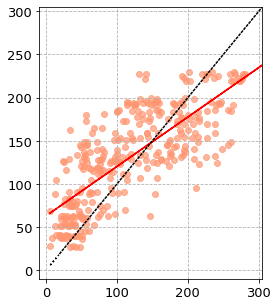

 6/11 [===============>..............] - ETA: 0s

2024-08-19 16:38:23.527616: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,5]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:23.528196: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,5]
	 [[{{node Placeholder/_10}}]]


11/11 [==============================] - 0s 10ms/step
----------------
combi name : sunlight
 R2: 24.098714433, RMSE: 65.0661322607, MAE: 55.071378175
----------------


<Figure size 432x288 with 0 Axes>

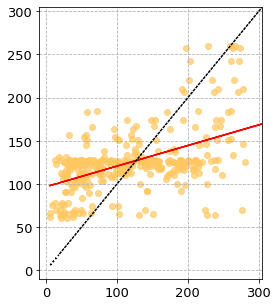

11/11 [==============================] - 0s 1ms/step
----------------
combi name : soiling
 R2: 23.817765575, RMSE: 65.1864422828, MAE: 53.5250320719
----------------


2024-08-19 16:38:24.032422: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,6]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:24.032801: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,6]
	 [[{{node Placeholder/_10}}]]


<Figure size 432x288 with 0 Axes>

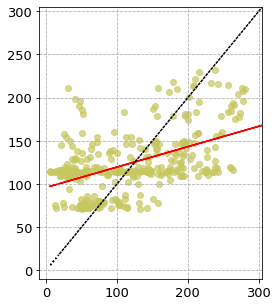

11/11 [==============================] - 0s 2ms/step
----------------
combi name : weather_sunlight
 R2: 59.876907606, RMSE: 47.3072414744, MAE: 36.7110659
----------------


2024-08-19 16:38:24.422664: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,9]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:24.423045: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,9]
	 [[{{node Placeholder/_10}}]]


<Figure size 432x288 with 0 Axes>

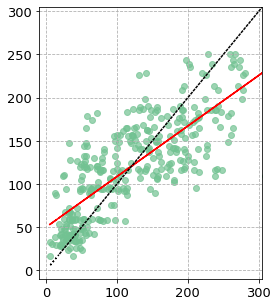

11/11 [==============================] - 0s 2ms/step
----------------
combi name : weather_soiling
 R2: 78.5046366138, RMSE: 34.6260396078, MAE: 24.368557795
----------------


2024-08-19 16:38:24.811254: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,10]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:24.811635: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,10]
	 [[{{node Placeholder/_10}}]]


<Figure size 432x288 with 0 Axes>

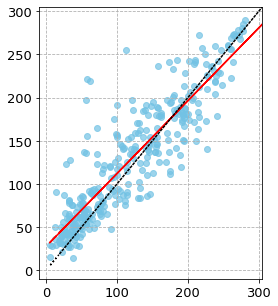

11/11 [==============================] - 0s 3ms/step
----------------
combi name : sunlight_soiling
 R2: 58.3649795967, RMSE: 48.1903207219, MAE: 34.7820005254
----------------


2024-08-19 16:38:25.266122: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,11]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:25.266480: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,11]
	 [[{{node Placeholder/_10}}]]


<Figure size 432x288 with 0 Axes>

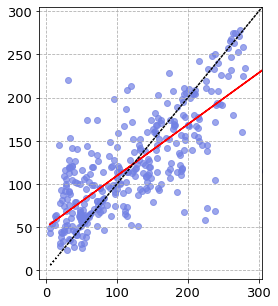

11/11 [==============================] - 0s 2ms/step
----------------
combi name : weather_sunlight_soiling
 R2: 81.2623386337, RMSE: 32.3286908895, MAE: 22.4365250531
----------------


2024-08-19 16:38:25.735107: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,15]
	 [[{{node Placeholder/_10}}]]
2024-08-19 16:38:25.735451: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype double and shape [340,15]
	 [[{{node Placeholder/_10}}]]


<Figure size 432x288 with 0 Axes>

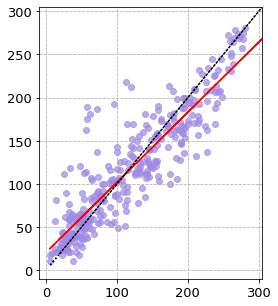

<Figure size 432x288 with 0 Axes>

In [38]:
from sklearn.linear_model import LinearRegression
from pickle import load
from silence_tensorflow import silence_tensorflow
import warnings
import matplotlib.pyplot as plt


results = {}

# Matplotlib의 기본 스타일 설정 변경
plt.rcParams['font.size'] = 13  # 전체 글꼴 크기
plt.rcParams['axes.labelsize'] = 10  # 축 레이블 크기
# plt.rcParams['xtick.labelsize'] = 10  # x축 눈금 레이블 크기
# plt.rcParams['ytick.labelsize'] = 10  # y축 눈금 레이블 크기
colors= ['#FF9671','#FFC75F','#C6C75F','#72C292','#72C2E4','#7281E4','#9F89E6']


for i, combi_name in enumerate(historys.keys()):
    plt.figure(figsize=(4, 5))
    # 저장했던거 불러오기
    X_test = pd.read_csv(f"{logs_folder}/{combi_name}/X_test.csv", index_col=0)
    y_test = pd.read_csv(f"{logs_folder}/{combi_name}/y_test.csv", index_col=0)

    model = models.load_model(f"{logs_folder}/{combi_name}/best_model.h5")
    scaler = load(open(f"{logs_folder}/{combi_name}/y_scaler.pkl", 'rb'))

    y_test_inv = y_scaler.inverse_transform(y_test)

    y_forecast = model.predict(X_test)
    y_forecast_inv = y_scaler.inverse_transform(y_forecast)
    y_forecast_inv = y_forecast_inv#.clip(min=0)

    r2, rmse, mae = evaluate(y_test_inv, y_forecast_inv)

    print("----------------")
    print(f"combi name : {combi_name}\n R2: {r2}, RMSE: {rmse}, MAE: {mae}")
    print("----------------")

    
    ## 그래프 그리기
    lr = LinearRegression()
    lr.fit(y_test_inv, y_forecast_inv)

    plt.grid(True, linestyle='--',  axis='y')
    plt.grid(True, linestyle='--',  axis='x')
    
    plt.scatter(y_test_inv, y_forecast_inv, color=colors[i], alpha=0.7) #color=colors[i]
    plt.plot(y_test_inv, lr.predict(y_test_inv), color='red', label='선형 회귀 직선')
    plt.plot(y_test_inv, y_test_inv, color='black', label='ideal', linestyle=':')
    plt.xlim([-10, 305]) 
    plt.ylim([-10, 305]) 
#     plt.axis('off')
    plt.show()

    plt.savefig(f'{logs_folder}/result_graph_{combi_name.replace("_","+")}.png') 

In [ ]:
y_test_inv.max(), y_forecast_inv.max()

In [ ]:
results